# How Good Is the Fit?

> *Adapted from teaching notebooks contributed by **Lei Qian**, who developed the regression
> material for this course.*

**This notebook is self-contained; it refits the line from the previous notebook before scoring it.**

We have a best-fitting line. That raises the obvious next question: **is it any good?** "Best" only
means it beat the other straight lines — it says nothing about whether a straight line was the right
idea at all.

This notebook builds the standard scorecard: how much of the variation in the data the line actually
explains, expressed as a single number between 0 and 1.

## Learning objectives

- Decompose the total variation into **SST = SSR + SSE**.
- Compute and interpret the **correlation coefficient** $r$ and the **coefficient of determination** $r^2$.
- Read the **standard error** as a typical prediction miss, in the units of the data.

## Background

Start with a baseline. If you knew nothing about chirp rate, your best guess for any temperature would
be the **mean** $\bar{y}$. The total variation to be explained is how far the data sits from that:

$$\text{SST} = \sum (y_i - \bar{y})^2 \qquad \text{(total sum of squares)}$$

The regression line splits that into two pieces:

$$\underbrace{\sum (y_i - \bar{y})^2}_{\text{SST, total}} \;=\;
  \underbrace{\sum (\hat{y}_i - \bar{y})^2}_{\text{SSR, explained by the line}} \;+\;
  \underbrace{\sum (y_i - \hat{y}_i)^2}_{\text{SSE, left over}}$$

The fraction the line explains is the **coefficient of determination**:

$$r^2 = \frac{\text{SSR}}{\text{SST}} = 1 - \frac{\text{SSE}}{\text{SST}}$$

$r^2 = 1$ means the line passes through every point; $r^2 = 0$ means it is no better than guessing the
mean. Its square root $r$, the **correlation coefficient**, carries a sign as well, running from $-1$
to $+1$ to say whether the relationship rises or falls.

Finally, the **standard error** $s_e = \sqrt{\text{SSE}/(n-2)}$ reports a typical miss in the original
units — degrees, here — which is often more useful than a unitless ratio.

## This notebook covers

1. Refitting the line.
2. The baseline: guessing the mean.
3. Splitting the variation: SST = SSR + SSE.
4. $r$ and $r^2$.
5. The standard error, and a library shortcut.

**Prerequisites:** `U3-7_Regression-1_FittingALine`

**Dataset:** `slr02.csv` — cricket chirps vs temperature, from the shared dataset library.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers
# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

## 1. The line, refitted

Same data and same closed-form formulas as the previous notebook, in one cell so this one stands alone.

In [2]:
# the file's first three lines are a header plus two lines of description, not data
crickets = pd.read_csv(helpers.data('MSDS 520 Calculus/slr02.csv'), skiprows=3,
                       names=['chirps', 'temperature'])
x = crickets['chirps'].values
y = crickets['temperature'].values

x_bar, y_bar = x.mean(), y.mean()
b1 = np.sum((x - x_bar)*(y - y_bar)) / np.sum((x - x_bar)**2)
b0 = y_bar - b1*x_bar
y_hat = b0 + b1*x                       # the line's predictions

print(f"n = {len(x)} observations")
print(f"fitted line: temperature = {b0:.4f} + {b1:.4f} x chirps")

n = 15 observations
fitted line: temperature = 25.2323 + 3.2911 x chirps


## 2. The baseline: what if we ignored chirps entirely?

Before crediting the line with anything, ask what a model with **no input** would do. Knowing nothing
about chirp rate, the best single guess for temperature is the **mean**.

The gaps from that flat line are the total variation, **SST**. That is the quantity the regression
line is trying to reduce — and its improvement over this baseline is exactly what $r^2$ measures.

In [3]:
SST = np.sum((y - y_bar)**2)
SSE = np.sum((y - y_hat)**2)
SSR = np.sum((y_hat - y_bar)**2)

print(f"SST (total, about the mean)  = {SST:10.4f}")
print(f"SSR (explained by the line)  = {SSR:10.4f}")
print(f"SSE (left over)              = {SSE:10.4f}")
print(f"\nSSR + SSE = {SSR + SSE:.4f}   vs   SST = {SST:.4f}")
print(f"do they match? {np.isclose(SSR + SSE, SST)}")

SST (total, about the mean)  =   629.8360
SSR (explained by the line)  =   439.2887
SSE (left over)              =   190.5473

SSR + SSE = 629.8360   vs   SST = 629.8360
do they match? True


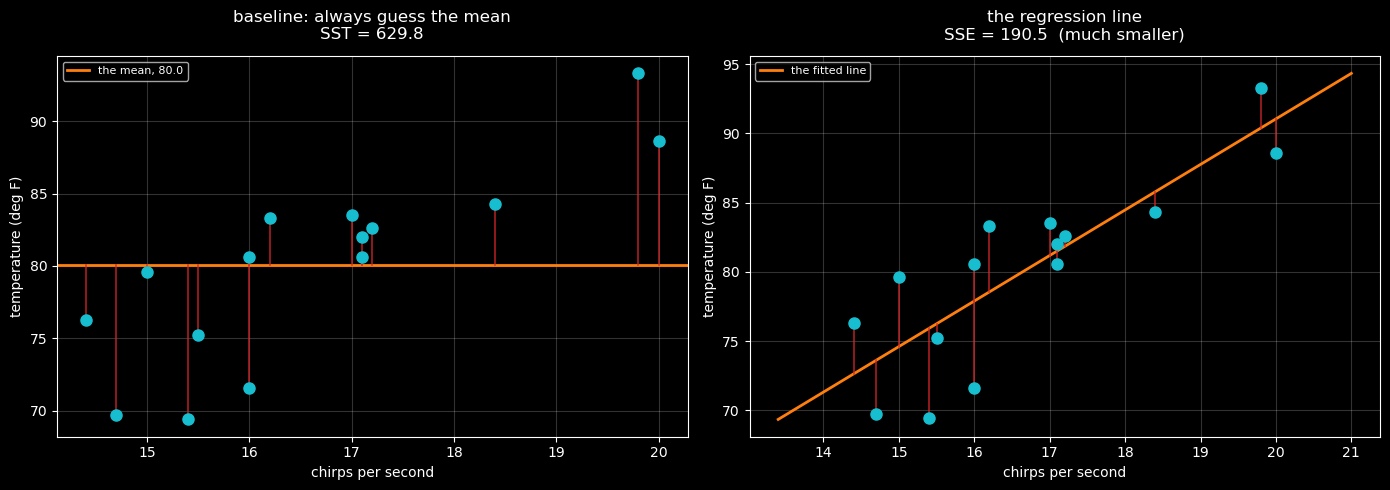

In [4]:
grid = np.linspace(x.min() - 1, x.max() + 1, 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(x, y, "o", color="tab:cyan", markersize=8, zorder=5)
axes[0].axhline(y_bar, color="tab:orange", lw=2, label=f"the mean, {y_bar:.1f}")
for xi, yi in zip(x, y):
    axes[0].plot([xi, xi], [yi, y_bar], "-", color="tab:red", lw=1.2, alpha=0.8)
axes[0].set_title(f"baseline: always guess the mean\nSST = {SST:.1f}", pad=12)
axes[0].legend(fontsize=8)

axes[1].plot(x, y, "o", color="tab:cyan", markersize=8, zorder=5)
axes[1].plot(grid, b0 + b1*grid, color="tab:orange", lw=2, label="the fitted line")
for xi, yi, yh in zip(x, y, y_hat):
    axes[1].plot([xi, xi], [yi, yh], "-", color="tab:red", lw=1.2, alpha=0.8)
axes[1].set_title(f"the regression line\nSSE = {SSE:.1f}  (much smaller)", pad=12)
axes[1].legend(fontsize=8)

for ax in axes:
    ax.set_xlabel("chirps per second"); ax.set_ylabel("temperature (deg F)")
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 3. The split, as a picture

For a single data point, the gap from the mean breaks cleanly into two parts: the bit the line moved
you (**explained**) and the bit still remaining (**unexplained**). Summed over all points and squared,
those are SSR and SSE.

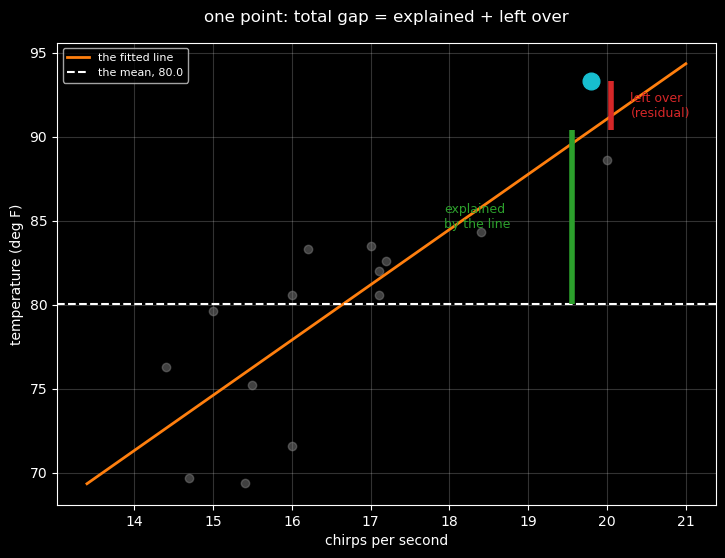

In [5]:
i = int(np.argmax(np.abs(y - y_bar)))         # the point furthest from the mean
xi, yi, yh = x[i], y[i], y_hat[i]

fig, ax = plt.subplots(figsize=(8.5, 6))
ax.plot(x, y, "o", color="gray", markersize=6, alpha=0.5)
ax.plot(grid, b0 + b1*grid, color="tab:orange", lw=2, label="the fitted line")
ax.axhline(y_bar, color="white", lw=1.5, ls="--", label=f"the mean, {y_bar:.1f}")
ax.plot(xi, yi, "o", color="tab:cyan", markersize=12, zorder=6)

ax.plot([xi - 0.25, xi - 0.25], [y_bar, yh], lw=4, color="tab:green", solid_capstyle="butt")
ax.plot([xi + 0.25, xi + 0.25], [yh, yi], lw=4, color="tab:red", solid_capstyle="butt")
ax.annotate("explained\nby the line", (xi - 0.25, (y_bar + yh)/2), textcoords="offset points",
            xytext=(-92, -8), color="tab:green", fontsize=9)
ax.annotate("left over\n(residual)", (xi + 0.25, (yh + yi)/2), textcoords="offset points",
            xytext=(14, -8), color="tab:red", fontsize=9)

ax.set_xlabel("chirps per second"); ax.set_ylabel("temperature (deg F)")
ax.legend(loc="upper left", fontsize=8)
ax.grid(alpha=0.2)
ax.set_title("one point: total gap = explained + left over", pad=15)
plt.show()

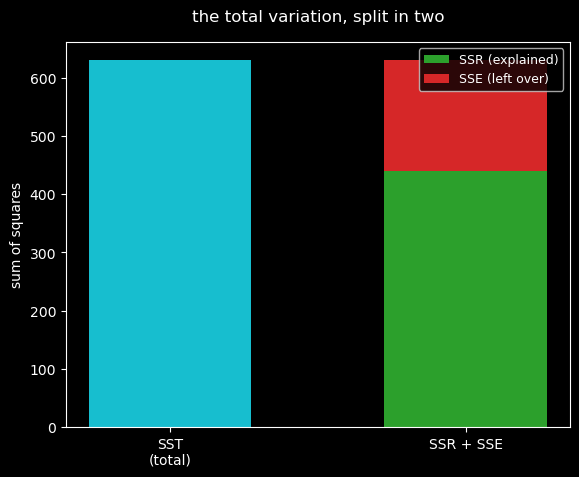

the line explains 69.7% of the total variation
and leaves        30.3% unexplained


In [6]:
# the same split as stacked bars, for the whole dataset
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.bar(["SST\n(total)"], [SST], color="tab:cyan", width=0.55)
ax.bar(["SSR + SSE"], [SSR], color="tab:green", width=0.55, label="SSR (explained)")
ax.bar(["SSR + SSE"], [SSE], bottom=[SSR], color="tab:red", width=0.55, label="SSE (left over)")
ax.set_ylabel("sum of squares")
ax.legend(fontsize=9)
ax.set_title("the total variation, split in two", pad=15)
plt.show()

print(f"the line explains {SSR/SST*100:.1f}% of the total variation")
print(f"and leaves        {SSE/SST*100:.1f}% unexplained")

## 4. $r$ and $r^2$

Now the headline numbers.

$$r^2 = \frac{\text{SSR}}{\text{SST}} = 1 - \frac{\text{SSE}}{\text{SST}}$$

$r^2$ is the **proportion of variation explained**. Multiply by 100 and it is a percentage, which is
how it is usually reported.

The **correlation coefficient** $r$ is its signed square root — positive when the line slopes up,
negative when it slopes down. $r$ tells you direction *and* strength; $r^2$ tells you explanatory
power. Both are unitless, so they are comparable across completely different datasets.

In [7]:
r2 = SSR / SST
r = np.sign(b1) * np.sqrt(r2)

print(f"r^2 = SSR/SST      = {r2:.4f}    -> the line explains {r2*100:.1f}% of the variation")
print(f"r^2 = 1 - SSE/SST  = {1 - SSE/SST:.4f}    (the same, computed the other way)")
print(f"r   = sign(b1) sqrt(r^2) = {r:+.4f}   -> a strong POSITIVE relationship")
print()
print(f"numpy's correlation coefficient: {np.corrcoef(x, y)[0, 1]:+.4f}   (agrees)")

r^2 = SSR/SST      = 0.6975    -> the line explains 69.7% of the variation
r^2 = 1 - SSE/SST  = 0.6975    (the same, computed the other way)
r   = sign(b1) sqrt(r^2) = +0.8351   -> a strong POSITIVE relationship

numpy's correlation coefficient: +0.8351   (agrees)


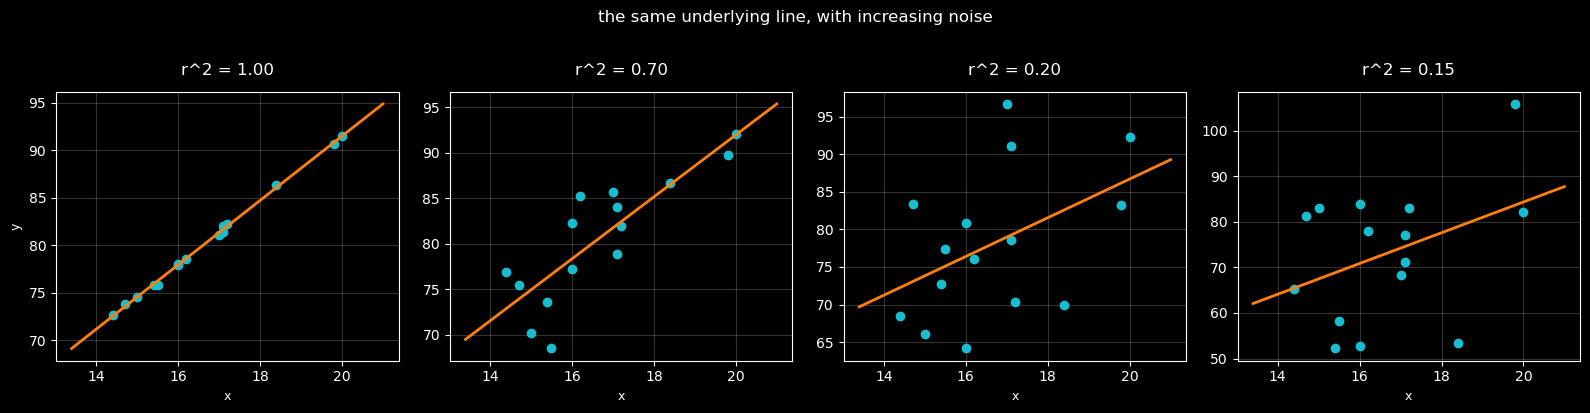

In [8]:
# what different r^2 values actually look like
np.random.seed(0)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, noise in zip(axes, [0.3, 3, 8, 20]):
    yy = 25 + 3.3*x + np.random.normal(0, noise, len(x))
    bb1 = np.sum((x - x.mean())*(yy - yy.mean())) / np.sum((x - x.mean())**2)
    bb0 = yy.mean() - bb1*x.mean()
    pred = bb0 + bb1*x
    rr2 = 1 - np.sum((yy - pred)**2) / np.sum((yy - yy.mean())**2)
    ax.plot(x, yy, "o", color="tab:cyan", markersize=6)
    ax.plot(grid, bb0 + bb1*grid, color="tab:orange", lw=2)
    ax.set_title(f"r^2 = {rr2:.2f}", pad=12)
    ax.set_xlabel("x", fontsize=9)
    ax.grid(alpha=0.2)
axes[0].set_ylabel("y", fontsize=9)
plt.suptitle("the same underlying line, with increasing noise", y=1.02)
plt.tight_layout()
plt.show()

A caution worth carrying: a high $r^2$ says the **straight line** fits well. It does not say the
relationship is causal, and it does not say a straight line was the right shape — a curve badly fitted
by a line can still score respectably.

## 5. The standard error, and the library shortcut

$r^2$ is unitless, which makes it comparable but abstract. The **standard error of the estimate**
gives a typical miss in the actual units:

$$s_e = \sqrt{\frac{\text{SSE}}{n-2}}$$

(We divide by $n-2$ rather than $n$ because two parameters, $b_0$ and $b_1$, were estimated from this
same data.) For this dataset it answers a concrete question: *if I predict the temperature from a
cricket's chirp rate, how many degrees off am I likely to be?*

Finally, everything above is one call in `scipy.stats` — worth knowing now that you can compute it by
hand and know what each output means.

In [9]:
n = len(x)
se = np.sqrt(SSE / (n - 2))
print(f"standard error = sqrt(SSE / (n-2)) = sqrt({SSE:.3f} / {n-2}) = {se:.4f} degrees F")
print(f"\nSo a prediction from this line is typically off by about {se:.1f} degrees.")
print(f"For comparison, the temperatures themselves range over {y.max() - y.min():.1f} degrees.")

standard error = sqrt(SSE / (n-2)) = sqrt(190.547 / 13) = 3.8285 degrees F

So a prediction from this line is typically off by about 3.8 degrees.
For comparison, the temperatures themselves range over 23.9 degrees.


In [10]:
from scipy import stats

result = stats.linregress(x, y)
print("scipy.stats.linregress, all at once:\n")
print(f"  slope       {result.slope:10.4f}   (ours: {b1:.4f})")
print(f"  intercept   {result.intercept:10.4f}   (ours: {b0:.4f})")
print(f"  r           {result.rvalue:10.4f}   (ours: {r:.4f})")
print(f"  r^2         {result.rvalue**2:10.4f}   (ours: {r2:.4f})")
print(f"  p-value     {result.pvalue:10.3e}   (how likely this is chance)")

scipy.stats.linregress, all at once:

  slope           3.2911   (ours: 3.2911)
  intercept      25.2323   (ours: 25.2323)
  r               0.8351   (ours: 0.8351)
  r^2             0.6975   (ours: 0.6975)
  p-value      1.067e-04   (how likely this is chance)


## 6. Summary

- The baseline is **guessing the mean**; the total variation about it is **SST**.
- The line splits that total: **SST = SSR + SSE**, explained plus left over.
- **$r^2 = \text{SSR}/\text{SST}$** is the proportion of variation the line explains — 0 means no
  better than the mean, 1 means a perfect fit.
- **$r$** is the signed square root: direction and strength together.
- The **standard error** $\sqrt{\text{SSE}/(n-2)}$ is a typical miss in the original units.
- A high $r^2$ does not prove causation, nor that a straight line was the right shape.

Next: the same line found three completely different ways — including by the gradient descent of
`U3-7_GradientDescent-1_Descent` (`U3-7_Regression-3_ThreeWays`).